In [1]:
#import libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import warnings

#suppress warnings
warnings.filterwarnings("ignore")

In [2]:
#import data
gender_submission = pd.read_csv('../input/titanic/gender_submission.csv')
test_data = pd.read_csv('../input/titanic/test.csv')
train_data = pd.read_csv('../input/titanic/train.csv')

# Initial EDA

In [3]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train_data.describe().columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [7]:
train_data.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [8]:
#numerical variables
numerical = [
    'PassengerId',
    'Age',
    'SibSp',
    'Parch',
    'Fare'
]

#categorical variables
categorical = [
    'Name',
    'Sex',
    'Pclass',
    'Ticket',
    'Cabin',
    'Embarked',
    'Survived'
]

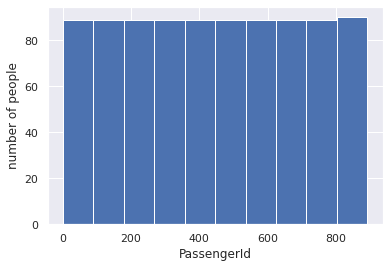

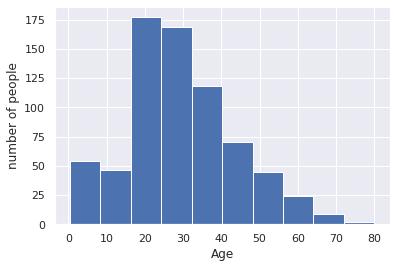

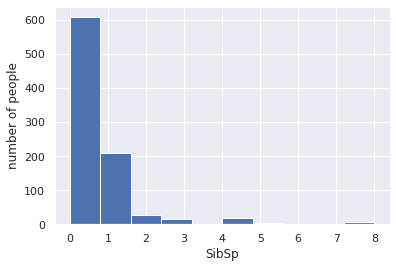

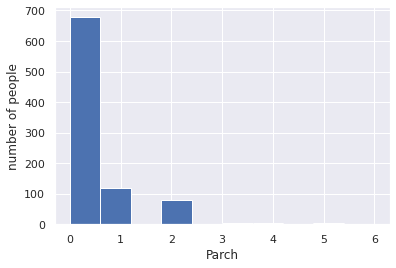

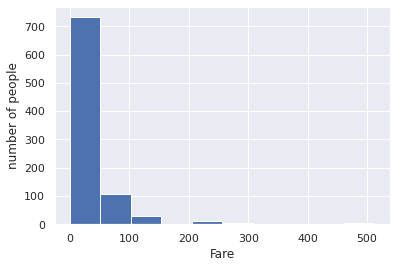

In [9]:
#numerical data distribution
for i in train_data[numerical].columns:
    plt.hist(train_data[numerical][i])
    plt.xticks()
    plt.xlabel(i)
    plt.ylabel('number of people')
    plt.show()

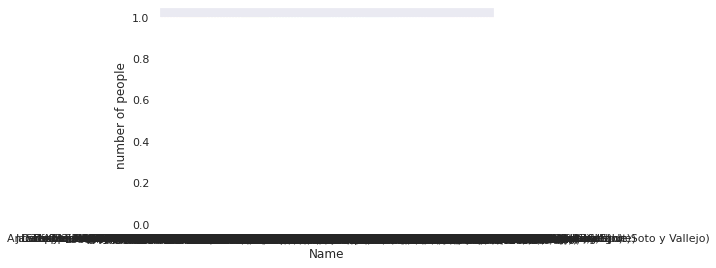

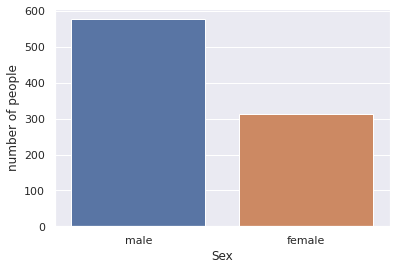

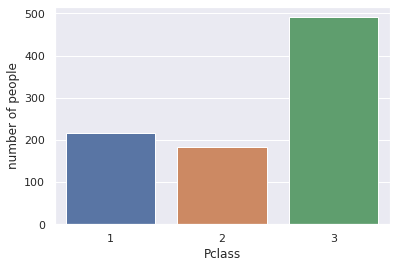

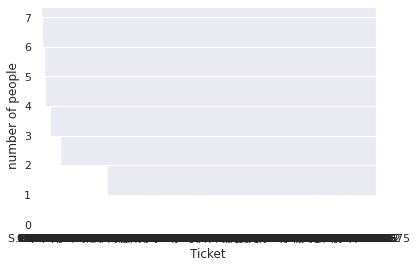

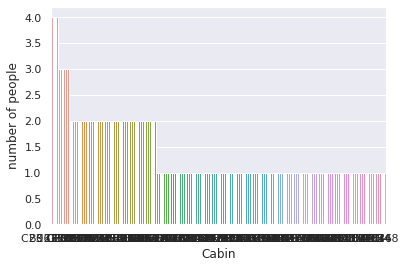

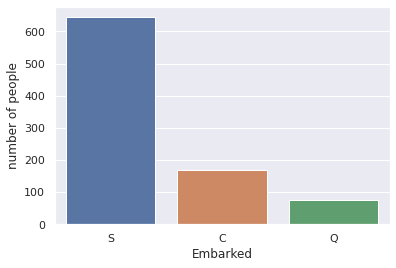

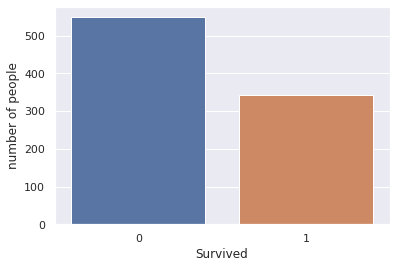

In [10]:
#categorical data distribution
for i in train_data[categorical].columns:
    sns.barplot(x=train_data[categorical][i].value_counts().index,y=train_data[categorical][i].value_counts())
    plt.xlabel(i)
    plt.ylabel('number of people')
    plt.show()

# Cleaning

1. Seperate ticket into two parts: prefix and number
2. Seperate name into two parts: title and last name
3. Remove ticket, name, cabin, and id columns

In [11]:
#splits the ticket column into three parts and puts "empty" if ticket part does not exist

def split_ticket(df):
    
    ticket_part_1 = []
    ticket_part_2 = []
    ticket_part_3 = []
    
    for ticket in df.Ticket:

        if len(ticket.split(' ')) == 2:
            part_2, part_1 = ticket.split(' ')
            ticket_part_1.append(part_1)
            ticket_part_2.append(part_2)
            ticket_part_3.append('empty')

        elif len(ticket.split(' ')) == 3:
            part_3, part_2, part_1 = ticket.split(' ')
            ticket_part_1.append(part_1)
            ticket_part_2.append(part_2)
            ticket_part_3.append(part_3)

        else:
            ticket_part_1.append(ticket)
            ticket_part_2.append('empty')
            ticket_part_3.append('empty')
            
    split_ticket = pd.DataFrame([np.array(ticket_part_3), np.array(ticket_part_2), np.array(ticket_part_1)]).T
    
    split_ticket.columns = ['Ticket_3', 'Ticket_2', 'Ticket_1']
    
    return split_ticket

In [12]:
#fixing what looks like misprints in ticket column

def fix_ticket(df):
    
    for i in df.Ticket:
        if 'STON/O2.' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'STON/O 2. {}'.format(num)
            
    for i in df.Ticket:
        if 'SOTON/O2 ' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'STON/O 2. {}'.format(num)
            
    for i in df.Ticket:
        if 'A/5.' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'A/5 {}'.format(num)

    for i in df.Ticket:
        if 'A./5.' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'A/5 {}'.format(num)
            
    for i in df.Ticket:
        if 'A.5.' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'A/5 {}'.format(num)
            
    for i in df.Ticket:
        if 'A/S' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'A/5 {}'.format(num)
            
    for i in df.Ticket:
        if 'A/4.' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'A/4 {}'.format(num)
            
    for i in df.Ticket:
        if 'A4.' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'A/4 {}'.format(num)
            
    for i in df.Ticket:
        if 'SOTON/OQ' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'SOTON/O.Q. {}'.format(num)
            
    for i in df.Ticket:
        if 'C.A./SOTON' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'SOTON/C.A. {}'.format(num)
            
    for i in df.Ticket:
        if 'CA ' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'C.A. {}'.format(num)
            
    for i in df.Ticket:
        if 'CA. ' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'C.A. {}'.format(num)
    
    for i in df.Ticket:
        if 'SC/Paris ' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'PC/PARIS {}'.format(num)
            
    for i in df.Ticket:
        if 'S.C./PARIS ' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'PC/PARIS {}'.format(num)
            
    for i in df.Ticket:
        if 'W/C ' in i:
            throw_out, num = i.split(' ')
            df.Ticket[df.Ticket == i] = 'W./C. {}'.format(num)
    
            
    return df

In [13]:
#fix then split training data
train_data = fix_ticket(train_data)
split_train = split_ticket(train_data)

In [14]:
#fix then split test data
test_data = fix_ticket(test_data)
split_test = split_ticket(test_data)

In [15]:
#make a two column ticket dataframe where column 1 is the number part and column two is the string part

def two_column_ticket(df):
    
    ticket_column_1 = []
    ticket_column_2 = []
    
    for ticket in df.Ticket:

        if len(ticket.split(' ')) == 2:
            part_2, part_1 = ticket.split(' ')
            ticket_column_1.append(part_1)
            ticket_column_2.append(part_2)

        elif len(ticket.split(' ')) == 3:
            part_3, part_2, part_1 = ticket.split(' ')
            ticket_column_1.append(part_1)
            ticket_column_2.append('{} {}'.format(part_3,part_2))
            
        elif 'LINE' in ticket:
            ticket_column_1.append(np.nan)
            ticket_column_2.append(ticket)

        else:
            ticket_column_1.append(ticket)
            ticket_column_2.append('empty')
            
    two_column_ticket = pd.DataFrame([np.array(ticket_column_2), np.array(ticket_column_1)]).T
    
    two_column_ticket.columns = ['Ticket_2', 'Ticket_1']
    
    return two_column_ticket
    

In [16]:
#make two two-column dataframes (one for training one for test)
two_column_train = two_column_ticket(train_data)
two_column_test = two_column_ticket(test_data)

In [17]:
#add two column ticket to each dataframe
train_data['Ticket_Num'] = two_column_train.Ticket_1
test_data['Ticket_Num'] = two_column_test.Ticket_1

train_data['Ticket_Prefix'] = two_column_train.Ticket_2
test_data['Ticket_Prefix'] = two_column_test.Ticket_2

#add new columns to numerical and categorical variable arrays
numerical.append('Ticket_Num')
categorical.append('Ticket_Prefix')

#remove ticket columns and remove ticket variable from categorical
train_data = train_data.drop('Ticket',axis=1)
test_data = test_data.drop('Ticket',axis=1)
categorical.remove('Ticket')

In [18]:
#get titles from name column (e.g., Mr., Ms., Dr.)

import re

def get_titles(df):
    
    titles=[]

    for i in df.Name:
        
        titles.append(re.findall(r'(?<=,\s)[a-z]+.',i,re.I))
        
    return titles

In [19]:
titles_train = get_titles(train_data)
titles_test = get_titles(test_data)

train_data['Title'] = titles_train
test_data['Title'] = titles_test

categorical.append('Title')

In [20]:
for i in range(len(train_data.Title)):
    train_data.Title[i] = train_data.Title[i][0]

In [21]:
for i in range(len(test_data.Title)):
    test_data.Title[i] = test_data.Title[i][0]

In [22]:
def get_last_names(df):
    
    last_names=[]

    for i in df.Name:
        
        last_names.append(i.split(',')[0])
        
    return last_names

In [23]:
last_names_train = get_last_names(train_data)
last_names_test = get_last_names(test_data)

train_data['Last_Name'] = last_names_train
test_data['Last_Name'] = last_names_test

categorical.append('Last_Name')

In [24]:
train_data = train_data.drop('Cabin', axis=1)
test_data = test_data.drop('Cabin', axis=1)
categorical.remove('Cabin')

In [25]:
train_data = train_data.drop('Name', axis=1)
test_data = test_data.drop('Name', axis=1)
categorical.remove('Name')

In [26]:
train_data = train_data.drop('PassengerId',axis=1)
passenger_id = test_data.pop('PassengerId')
numerical.remove('PassengerId')

# EDA after Cleaning

In [27]:
train_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Ticket_Num,Ticket_Prefix,Title,Last_Name
0,0,3,male,22.0,1,0,7.2500,S,21171,A/5,Mr.,Braund
1,1,1,female,38.0,1,0,71.2833,C,17599,PC,Mrs.,Cumings
2,1,3,female,26.0,0,0,7.9250,S,3101282,STON/O 2.,Miss.,Heikkinen
3,1,1,female,35.0,1,0,53.1000,S,113803,empty,Mrs.,Futrelle
4,0,3,male,35.0,0,0,8.0500,S,373450,empty,Mr.,Allen


In [28]:
train_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


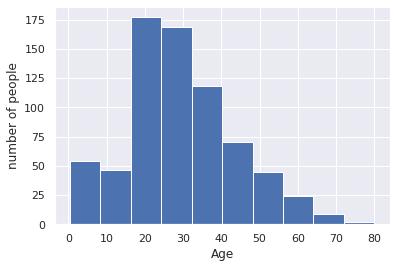

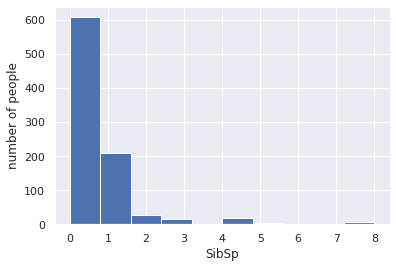

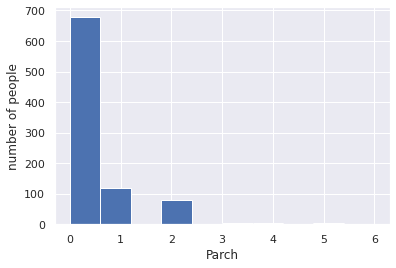

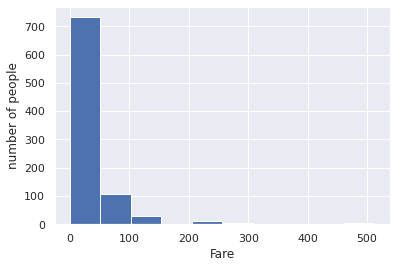

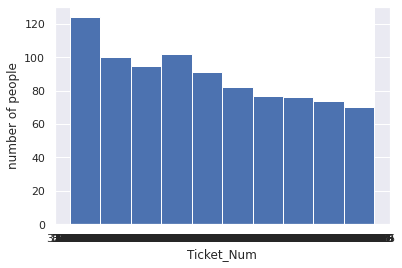

In [29]:
#numerical data distribution
for i in train_data[numerical].columns:
    plt.hist(train_data[numerical][i])
    plt.xticks()
    plt.xlabel(i)
    plt.ylabel('number of people')
    plt.show()

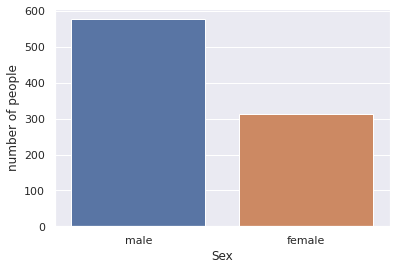

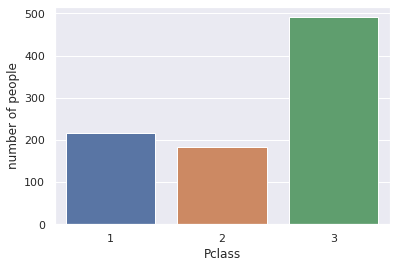

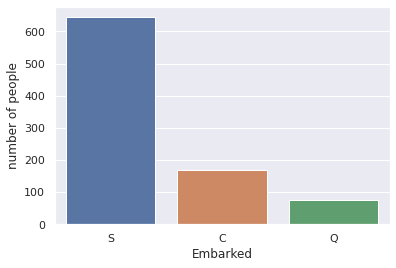

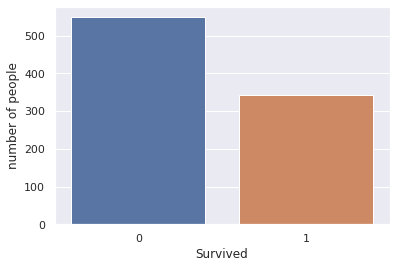

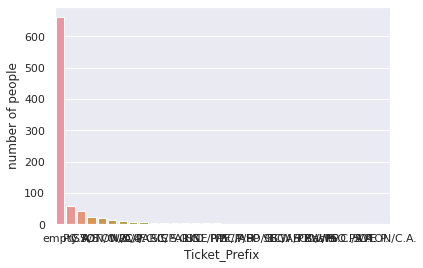

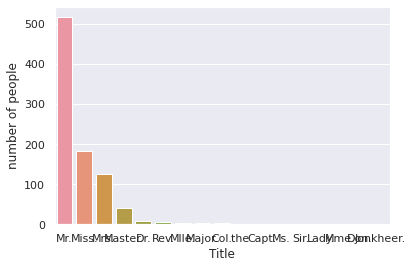

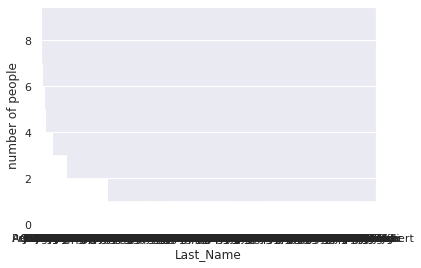

In [30]:
#categorical data distribution
for i in train_data[categorical].columns:
    sns.barplot(x=train_data[categorical][i].value_counts().index,y=train_data[categorical][i].value_counts())
    plt.xlabel(i)
    plt.ylabel('number of people')
    plt.show()

In [31]:
pd.pivot_table(train_data, values='Survived', index=['Embarked'], columns=['Pclass'], aggfunc=np.mean)

Pclass,1,2,3
Embarked,,,
C,0.694118,0.529412,0.378788
Q,0.500000,0.666667,0.375000
S,0.582677,0.463415,0.189802


In [32]:
pd.pivot_table(train_data, values='Survived', index=['Sex'], columns=['Pclass'], aggfunc=np.mean)

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


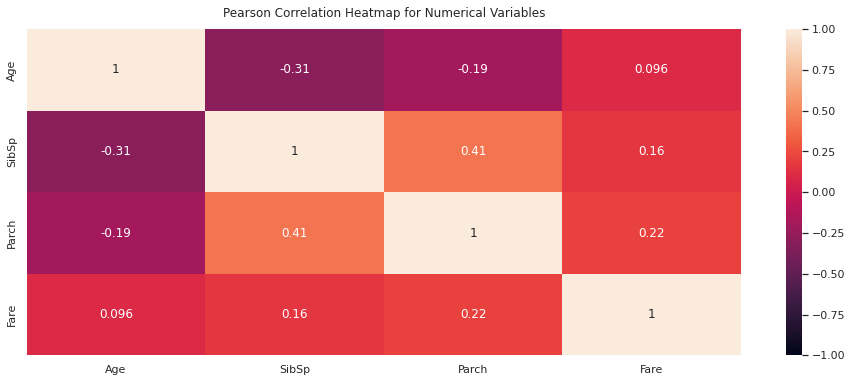

In [33]:
#heat map to see numerical correlations, pearson measures monotonic relationship (numerical or ordinal categorical)
plt.figure(figsize=(16, 6))
sns.heatmap(train_data[numerical].corr(method='pearson'), vmin=-1, vmax=1, annot=True)
plt.title('Pearson Correlation Heatmap for Numerical Variables', fontdict={'fontsize':12}, pad=12);

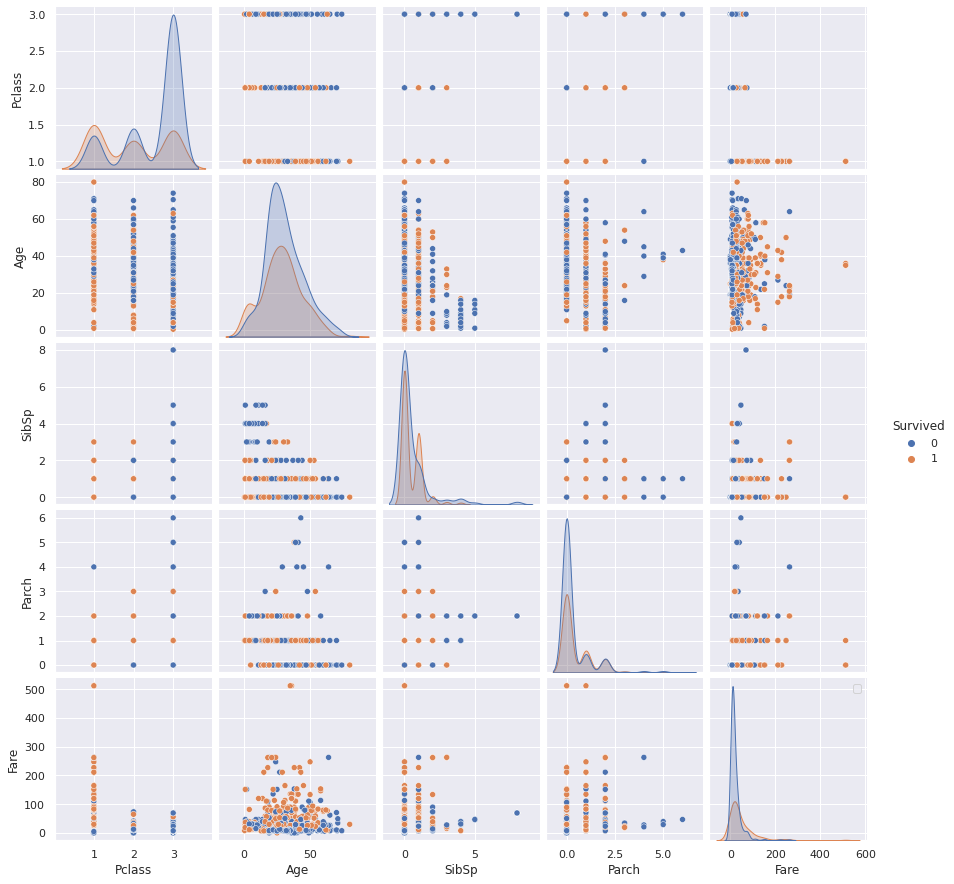

In [34]:
#look at how target is distributed among variables
sns.pairplot(train_data,hue='Survived')
plt.legend()
plt.show()

In [35]:
train_data.Title.unique()

array(['Mr.', 'Mrs.', 'Miss.', 'Master.', 'Don.', 'Rev.', 'Dr.', 'Mme.',
       'Ms.', 'Major.', 'Lady.', 'Sir.', 'Mlle.', 'Col.', 'Capt.', 'the ',
       'Jonkheer.'], dtype=object)

# Imputation, Create Dummies, and Scale

In [36]:
categorical.remove('Survived')

X_train = train_data.copy()
y_train = X_train.pop('Survived')

X_test = test_data.copy()

In [37]:
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
imp_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

for i in categorical:
    X_train[i] = imp_mode.fit_transform(X_train[i].values.reshape(-1,1))
    X_test[i] = imp_mode.fit_transform(X_test[i].values.reshape(-1,1))
for i in numerical:
    X_train[i] = imp_median.fit_transform(X_train[i].values.reshape(-1,1))
    X_test[i] = imp_median.fit_transform(X_test[i].values.reshape(-1,1))

In [38]:
#import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

#get feature names
X_train = pd.concat([X_train[numerical],pd.get_dummies(X_train[categorical])],axis=1)

#define scaler
scaler=MinMaxScaler()

#apply preprocessing to split data with scaler
X_train[numerical] = scaler.fit_transform(X_train[numerical])

In [39]:
#combine numerical and categorical/dummy variables into one dataframe
X_test = pd.concat([X_test[numerical],pd.get_dummies(X_test[categorical])],axis=1)

#scale test data
X_test[numerical] = scaler.transform(X_test[numerical])

In [40]:
#any dummy variables not in both train and test
difference = list(set(X_train.columns)-set(X_test.columns)) + list(set(X_test.columns)-set(X_train.columns))

#add columns to make train and test dataframes uniform
for i in difference:
    if i not in X_train.columns:
        X_train[i] = pd.DataFrame(index=range(len(X_train)),columns=[i])
        X_train.loc[:,i] = 0
    elif i not in X_test.columns:
        X_test[i] = pd.DataFrame(index=range(len(X_test)),columns=[i])
        X_test.loc[:,i] = 0    

# ML Model Baselines

In [41]:
#import ml algorithms
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from numpy import mean, std
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier

In [42]:
#naive Bayes with five-fold cross validation
gnb = GaussianNB()
cv = cross_val_score(gnb,X_train,y_train,cv=5)
print(mean(cv), '+/-', std(cv))

0.4937919779047141 +/- 0.01587393154806003


In [43]:
#logistic regression with five-fold cross validation
lr = LogisticRegression(max_iter = 2000)
cv = cross_val_score(lr,X_train,y_train,cv=5)
print(mean(cv), '+/-', std(cv))

0.8316301550436256 +/- 0.022320165981542975


In [44]:
#decession tree with five-fold cross validation
dt = tree.DecisionTreeClassifier(random_state = 1)
cv = cross_val_score(dt,X_train,y_train,cv=5)
print(mean(cv), '+/-', std(cv))

0.8395141547925429 +/- 0.03833035340409392


In [45]:
#random forest classifier with five-fold cross validation
rf = RandomForestClassifier(random_state = 1)
cv = cross_val_score(rf,X_train,y_train,cv=5)
print(mean(cv), '+/-', std(cv))

0.8237838177138912 +/- 0.025085605856906404


In [46]:
#support vector classifier with five-fold cross validation
svc = SVC(probability = True)
cv = cross_val_score(svc,X_train,y_train,cv=5)
print(mean(cv), '+/-', std(cv))

0.8271420500910176 +/- 0.021858994326326472


In [47]:
#k-nearest neighbors classifier with five-fold cross validation
knn = KNeighborsClassifier()
cv = cross_val_score(knn,X_train,y_train,cv=5)
print(mean(cv), '+/-', std(cv))

0.8137216747222397 +/- 0.021140034390436026


In [48]:
#xgboost classifier with five-fold cross validation
xgb = XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1)
cv = cross_val_score(xgb,X_train,y_train,cv=5)
print(mean(cv), '+/-', std(cv))

0.8305379448873266 +/- 0.03119692734253337


# Hyperparameter Tuning

In [49]:
#ml algorithm tuner
from sklearn.model_selection import GridSearchCV 

#performance reporting function
def clf_performance(classifier, model_name):
    print(model_name)
    print('Best Score: {} +/- {}'.format(str(classifier.best_score_),str(classifier.cv_results_['std_test_score'][classifier.best_index_])))
    print('Best Parameters: ' + str(classifier.best_params_))

In [50]:
#naive Bayes performance tuner
gnb = GaussianNB()
param_grid = {
              'var_smoothing': np.logspace(0,-10, num=100)
             }
clf_lr = GridSearchCV(gnb, param_grid = param_grid, cv = 5, n_jobs = -1)
best_clf_gnb = clf_lr.fit(X_train,y_train)
clf_performance(best_clf_gnb,'Naive Bayes')

Naive Bayes
Best Score: 0.7968489109283785 +/- 0.014927307670745302
Best Parameters: {'var_smoothing': 0.04862601580065353}


In [51]:
#logistic regression performance tuner
lr = LogisticRegression()
param_grid = {'max_iter' : [15000],
              'C' : np.arange(.5,1.5,.1)
             }
clf_lr = GridSearchCV(lr, param_grid = param_grid, cv = 5, n_jobs = -1)
best_clf_lr = clf_lr.fit(X_train,y_train)
clf_performance(best_clf_lr,'Logistic Regression')

Logistic Regression
Best Score: 0.8338836231247255 +/- 0.02508917734228222
Best Parameters: {'C': 1.2999999999999998, 'max_iter': 15000}


In [52]:
#decision tree performance tuner
dt = tree.DecisionTreeClassifier(random_state = 1)
param_grid = {
             'criterion':['gini','entropy'],
             'max_depth': np.arange(1, 15)
             }
clf_dt = GridSearchCV(dt, param_grid = param_grid, cv = 5, n_jobs = -1)
best_clf_dt = clf_dt.fit(X_train,y_train)
clf_performance(best_clf_dt,'Decision Tree')

Decision Tree
Best Score: 0.843977151465696 +/- 0.030934374696784093
Best Parameters: {'criterion': 'gini', 'max_depth': 13}


In [53]:
#k-nearest neighbors classifier performance tuner
knn = KNeighborsClassifier()
param_grid = {
              'n_neighbors' : np.arange(5,50,5),
              'weights' : ['uniform', 'distance'],
              'algorithm' : ['auto', 'ball_tree','kd_tree','brute'],
              'p' : [2,3,4,5]
             }
clf_knn = GridSearchCV(knn, param_grid = param_grid, cv = 5, n_jobs = -1)
best_clf_knn = clf_knn.fit(X_train,y_train)
clf_performance(best_clf_knn,'K-Nearest Neighbors Classifier')

K-Nearest Neighbors Classifier
Best Score: 0.835019772770071 +/- 0.02831609523133274
Best Parameters: {'algorithm': 'auto', 'n_neighbors': 20, 'p': 2, 'weights': 'distance'}


In [54]:
#random forest performance tuner
rf = RandomForestClassifier(random_state = 1)
param_grid =  {
                'n_estimators': np.arange(100,300,10), 
                'bootstrap': [False], #bagging (T) vs. pasting (F)
                'max_depth': np.arange(4,16,2),
                'max_features': ['auto'],
                'min_samples_leaf': [2],
                'min_samples_split': [2]
              }
clf_rf_rnd = GridSearchCV(rf, param_grid = param_grid, cv = 5, n_jobs = -1)
best_clf_rf_rnd = clf_rf_rnd.fit(X_train,y_train)
clf_performance(best_clf_rf_rnd,'Random Forest')

Random Forest
Best Score: 0.8147950536689473 +/- 0.02316733747808317
Best Parameters: {'bootstrap': False, 'max_depth': 12, 'max_features': 'auto', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 140}


In [55]:
#support vector classifier performance tuner
svc = SVC(probability = True, random_state = 1)
param_grid = {
              'kernel': ['linear','poly','sigmoid','rbf'],
              'gamma': [1, 1e-1, 1e-2, 1e-3, 1e-4],
#                'kernel': ['rbf'],
#                'gamma': [1],
               'C': np.arange(1,2,.1)
             }
clf_svc = GridSearchCV(svc, param_grid = param_grid, cv = 5, n_jobs = -1)
best_clf_svc = clf_svc.fit(X_train,y_train)
clf_performance(best_clf_svc,'Support Vector Classifier')

Support Vector Classifier
Best Score: 0.846218065407068 +/- 0.02043061756114974
Best Parameters: {'C': 1.6000000000000005, 'gamma': 0.1, 'kernel': 'poly'}


In [56]:
#xgboost classifier performance tuner
xgb = XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1)
param_grid = {
#               'max_depth': np.arange(2,12,2),
              'n_estimators': np.arange(50,200,50),
#               'learning_rate': [1.2]
             }
clf_xgb = GridSearchCV(xgb, param_grid = param_grid, cv = 5, n_jobs = -1)
best_clf_xgb = clf_xgb.fit(X_train,y_train)
clf_performance(best_clf_xgb,'XGBoost Classifier')

XGBoost Classifier
Best Score: 0.8305379448873266 +/- 0.03119692734253337
Best Parameters: {'n_estimators': 100}


# Ensemble Classifiers

In [57]:
#stacking def
def get_stacking():
    # define the base models
    level0 = list()
    level0.append(('gnb', GaussianNB(var_smoothing= 0.04862601580065353)))
    level0.append(('dt', tree.DecisionTreeClassifier(random_state = 1, criterion= 'gini', max_depth= 13)))
    level0.append(('lr', LogisticRegression(C= 1.3, max_iter= 15000)))
    level0.append(('knn', KNeighborsClassifier(algorithm= 'auto', n_neighbors= 20, p= 2, weights= 'distance')))
    level0.append(('rf', RandomForestClassifier(random_state = 1, bootstrap= False,max_depth= 12, max_features= 'auto', min_samples_leaf= 2, min_samples_split= 2, n_estimators= 140)))
    level0.append(('svc', SVC(probability = True, random_state = 1, gamma = .1, kernel= 'poly',C=1.6)))
    level0.append(('xgb', XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1, n_estimators=100)))
    # define meta learner model
    level1 = LogisticRegression()
    # define the stacking ensemble
    stacking_model = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
    return stacking_model

#models def
def get_models():
    models = dict()
    models['gnb'] = GaussianNB(var_smoothing= 0.04862601580065353)
    models['dt'] = tree.DecisionTreeClassifier(random_state = 1, criterion= 'gini', max_depth= 13)
    models['lr'] = LogisticRegression(C= 1.3, max_iter= 15000)
    models['knn'] = KNeighborsClassifier(algorithm= 'auto', n_neighbors= 20, p= 2, weights= 'distance')
    models['rf'] = RandomForestClassifier(random_state = 1, bootstrap= False,max_depth= 12, max_features= 'auto', min_samples_leaf= 2, min_samples_split= 2, n_estimators= 140)
    models['svc'] = SVC(probability = True, random_state = 1, gamma = .1, kernel= 'poly',C=1.6)
    models['xgb'] = XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1, n_estimators=100)
    models['stacking'] = get_stacking()
    return models

#cross validate models and print results
models = get_models()
results, names = list(),list()
print('Mean accuracy:')
for name, model in models.items():
    scores = cross_val_score(model,X_train,y_train, scoring='accuracy', cv=5, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print('>%s %.3f +/- %.3f' % (name, mean(scores), std(scores)))

Mean accuracy:
>gnb 0.797 +/- 0.015
>dt 0.844 +/- 0.031
>lr 0.834 +/- 0.025
>knn 0.835 +/- 0.028
>rf 0.815 +/- 0.023
>svc 0.846 +/- 0.020
>xgb 0.831 +/- 0.031
>stacking 0.841 +/- 0.021


In [58]:
#stacking def
def get_hard_voting():
    # define the base models
    level0 = list()
    level0.append(('gnb', GaussianNB(var_smoothing= 0.04862601580065353)))
    level0.append(('dt', tree.DecisionTreeClassifier(random_state = 1, criterion= 'gini', max_depth= 13)))
    level0.append(('lr', LogisticRegression(C= 1.3, max_iter= 15000)))
    level0.append(('knn', KNeighborsClassifier(algorithm= 'auto', n_neighbors= 20, p= 2, weights= 'distance')))
    level0.append(('rf', RandomForestClassifier(random_state = 1, bootstrap= False,max_depth= 12, max_features= 'auto', min_samples_leaf= 2, min_samples_split= 2, n_estimators= 140)))
    level0.append(('svc', SVC(probability = True, random_state = 1, gamma = .1, kernel= 'poly',C=1.6)))
    level0.append(('xgb', XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1, n_estimators=100)))
    hard_voting_model = VotingClassifier(estimators=level0, voting='hard')
    return hard_voting_model

#models def
def get_models():
    models = dict()
    models['gnb'] = GaussianNB(var_smoothing= 0.04862601580065353)
    models['dt'] = tree.DecisionTreeClassifier(random_state = 1, criterion= 'gini', max_depth= 13)
    models['lr'] = LogisticRegression(C= 1.3, max_iter= 15000)
    models['knn'] = KNeighborsClassifier(algorithm= 'auto', n_neighbors= 20, p= 2, weights= 'distance')
    models['rf'] = RandomForestClassifier(random_state = 1, bootstrap= False,max_depth= 12, max_features= 'auto', min_samples_leaf= 2, min_samples_split= 2, n_estimators= 140)
    models['svc'] = SVC(probability = True, random_state = 1, gamma = .1, kernel= 'poly',C=1.6)
    models['xgb'] = XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1, n_estimators=100)
    models['hv'] = get_hard_voting()
    return models

#cross validate models and print results
models = get_models()
results, names = list(),list()
print('Mean accuracy:')
for name, model in models.items():
    scores = cross_val_score(model,X_train,y_train, scoring='accuracy', cv=5, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print('>%s %.3f +/- %.3f' % (name, mean(scores), std(scores)))

Mean accuracy:
>gnb 0.797 +/- 0.015
>dt 0.844 +/- 0.031
>lr 0.834 +/- 0.025
>knn 0.835 +/- 0.028
>rf 0.815 +/- 0.023
>svc 0.846 +/- 0.020
>xgb 0.831 +/- 0.031
>hv 0.839 +/- 0.021


In [59]:
#stacking def
def get_soft_voting():
    # define the base models
    level0 = list()
    level0.append(('gnb', GaussianNB(var_smoothing= 0.04862601580065353)))
    level0.append(('dt', tree.DecisionTreeClassifier(random_state = 1, criterion= 'gini', max_depth= 13)))
    level0.append(('lr', LogisticRegression(C= 1.3, max_iter= 15000)))
    level0.append(('knn', KNeighborsClassifier(algorithm= 'auto', n_neighbors= 20, p= 2, weights= 'distance')))
    level0.append(('rf', RandomForestClassifier(random_state = 1, bootstrap= False,max_depth= 12, max_features= 'auto', min_samples_leaf= 2, min_samples_split= 2, n_estimators= 140)))
    level0.append(('svc', SVC(probability = True, random_state = 1, gamma = .1, kernel= 'poly',C=1.6)))
    level0.append(('xgb', XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1, n_estimators=100)))
    # define meta learner model
    soft_voting_model = VotingClassifier(estimators=level0, voting='soft')
    return soft_voting_model

#models def
def get_models():
    models = dict()
    models['gnb'] = GaussianNB(var_smoothing= 0.04862601580065353)
    models['dt'] = tree.DecisionTreeClassifier(random_state = 1, criterion= 'gini', max_depth= 13)
    models['lr'] = LogisticRegression(C= 1.3, max_iter= 15000)
    models['knn'] = KNeighborsClassifier(algorithm= 'auto', n_neighbors= 20, p= 2, weights= 'distance')
    models['rf'] = RandomForestClassifier(random_state = 1, bootstrap= False,max_depth= 12, max_features= 'auto', min_samples_leaf= 2, min_samples_split= 2, n_estimators= 140)
    models['svc'] = SVC(probability = True, random_state = 1, gamma = .1, kernel= 'poly',C=1.6)
    models['xgb'] = XGBClassifier(use_label_encoder=False, eval_metric='error', random_state =1, n_estimators=100)
    models['sv'] = get_soft_voting()
    return models

#cross validate models and print results
models = get_models()
results, names = list(),list()
print('Mean accuracy:')
for name, model in models.items():
    scores = cross_val_score(model,X_train,y_train, scoring='accuracy', cv=5, n_jobs=-1)
    results.append(scores)
    names.append(name)
    print('>%s %.3f +/- %.3f' % (name, mean(scores), std(scores)))

Mean accuracy:
>gnb 0.797 +/- 0.015
>dt 0.844 +/- 0.031
>lr 0.834 +/- 0.025
>knn 0.835 +/- 0.028
>rf 0.815 +/- 0.023
>svc 0.846 +/- 0.020
>xgb 0.831 +/- 0.031
>sv 0.843 +/- 0.026


# Prediction and Submission

In [60]:
dt_model = tree.DecisionTreeClassifier(random_state = 1, criterion= 'gini', max_depth= 13)
dt_model.fit(X_train,y_train)
predictions1 = dt_model.predict(X_test)

output = pd.DataFrame({'PassengerId': passenger_id, 'Survived': predictions1})
output.to_csv('submission1.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [61]:
svc_model = SVC(probability = True, random_state = 1, gamma = .1, kernel= 'poly',C=1.6)
svc_model.fit(X_train,y_train)
predictions2 = svc_model.predict(X_test)

output = pd.DataFrame({'PassengerId': passenger_id, 'Survived': predictions2})
output.to_csv('submission2.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [62]:
stacking_model = get_stacking()
stacking_model.fit(X_train,y_train)
predictions3 = stacking_model.predict(X_test)

output = pd.DataFrame({'PassengerId': passenger_id, 'Survived': predictions3})
output.to_csv('submission3.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [63]:
hv_model = get_hard_voting()
hv_model.fit(X_train,y_train)
predictions4 = hv_model.predict(X_test)

output = pd.DataFrame({'PassengerId': passenger_id, 'Survived': predictions4})
output.to_csv('submission4.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


In [64]:
sv_model = get_soft_voting()
sv_model.fit(X_train,y_train)
predictions5 = sv_model.predict(X_test)

output = pd.DataFrame({'PassengerId': passenger_id, 'Survived': predictions5})
output.to_csv('submission5.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!


# Soft Voting Classifier Test Accuracy: 0.78468